In [36]:
import polars as pl
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns
import utils

from matplotlib.colors import LinearSegmentedColormap

from sklearn.cluster import *
from sklearn.decomposition import PCA
from sklearn.preprocessing import *
from sklearn.metrics import *

FEATURES = ['coverage', 'diameter', 'est_apl', 'transitivity', 'density']

def plot_clustering(df_prep, features, k, color, filename = None):
    features_str = ' '.join(features)
    clust_data = PowerTransformer().fit_transform(df_prep[features])
    kmeans = KMeans(init='k-means++', n_clusters=k, n_init=100, max_iter=1000, random_state=1)
    pred_labels = kmeans.fit_predict(clust_data)
    sil = silhouette_score(clust_data, pred_labels)
    result = pl.DataFrame(clust_data).with_columns(label = pred_labels).to_pandas()
    plt.figure(figsize=(3, 3))
    plt.title(f'Features: [{features_str}]\nSilhouette: {round(sil, 6)}')
    sns.countplot(x='label', color=color, data=result)
    plt.xlabel('Cluster ID')
    plt.ylabel('N. of contracts')
    plt.grid(which='major', linestyle='--', linewidth=0.5)
    plt.grid(which='minor', linestyle='--', linewidth=0.5, alpha=0.2)
    plt.minorticks_on()
    plt.ylim(top=105)
    utils.set_font_size(plt.gca(), 14)
    if (not (filename is None)):
        plt.savefig(filename, format='pdf', bbox_inches='tight')
    plt.show()

# Clustering analysis

In this notebook we analyze the results of our clustering analysis.

## Results for ERC-20 tokens

In [24]:
ft_prep = pl.read_csv('results/ft/clustering/ft_prep.csv')
ft_prep

rank,category,category_id,comp_nodes,coverage,diameter,est_apl,transitivity,density
i64,str,i64,i64,f64,f64,f64,f64,f64
0,"""defi""",0,23175878,0.999986,2.948353,0.21861,0.000015,2.4854e-7
1,"""defi""",0,1093419,0.975073,2.085608,0.27473,0.006812,0.000008
2,"""defi""",0,8235742,0.999985,3.893496,0.255894,0.000015,5.3095e-7
3,"""defi""",0,1747934,0.998839,2.22625,0.287544,0.000093,0.000003
4,"""other""",1,2374247,0.999977,1.634856,0.29928,0.000019,0.000001
…,…,…,…,…,…,…,…,…
95,"""other""",1,295637,0.999746,1.587694,0.295035,0.000073,0.000011
96,"""other""",1,277703,0.999993,1.994526,0.309367,0.000046,0.000012
97,"""storage""",7,431525,1.0,0.308283,0.193321,0.000015,0.000008


In [3]:
ft_prep["category"].value_counts(sort=True)

category,count
str,u32
"""defi""",54
"""other""",15
"""gaming""",9
"""blockchain""",5
"""layer-2""",4
"""content""",4
"""storage""",4
"""mining""",3
"""multimedia""",2


This is the CSV file including all configurations tested with the K-Means algorithm. This file has one row for each configuration and each configuration is described by the following attributes.

- List of features used for the clustering.
- Number of clusters.
- Silhouette score of the clustering.
- Homogeneity score of the clustering (computed w.r.t. the manual labeling describing the contract semantics).

In [25]:
kmeans_results = pl.read_csv('results/ft/clustering/ft_kmeans.csv')
kmeans_results

features,k,silhouette,homogeneity
str,i64,f64,f64
"""coverage""",2,0.94502,0.019125
"""coverage""",3,0.936986,0.045896
"""coverage""",4,0.919401,0.063349
"""coverage""",5,0.91547,0.063349
"""coverage""",6,0.904286,0.063349
…,…,…,…
"""coverage diameter est_apl tran…",16,0.303858,0.329305
"""coverage diameter est_apl tran…",17,0.300943,0.31983
"""coverage diameter est_apl tran…",18,0.288219,0.331848


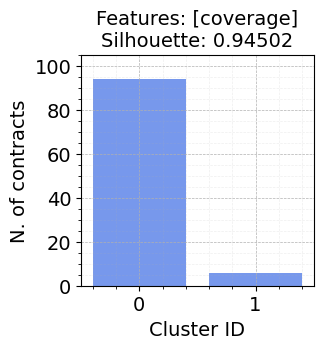

In [12]:
plot_clustering(ft_prep, ['coverage'], 2, color='#648fff', filename='figures/ft_kmeans_top_1.pdf')

### PCA

We conduct further analysis based on dimensionality reduction. In particular:

1. We use principal component analysis to reduce the number of features.
2. We execute the K-means algorithm on this reduced data set.

Before applying the dimensionality reduction we use the _explained variance ratio_ method to determine the optimal number of components.

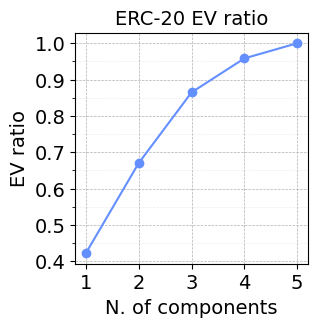

In [26]:
data = StandardScaler().fit_transform(ft_prep[FEATURES])
pca = PCA()
pca.fit(data)

fig, ax = plt.subplots(figsize=(3, 3))
ax.set_title('ERC-20 EV ratio')
ax.set_xlabel('N. of components')
ax.set_ylabel('EV ratio')
ax.plot(range(1, 6), pca.explained_variance_ratio_.cumsum(), marker='o', color='#648fff')
ax.grid(which='major', linestyle='--', linewidth=0.5)
ax.grid(which='minor', linestyle='--', linewidth=0.5, alpha=0.2)
#ax.xaxis.set_minor_locator(matplotlib.ticker.AutoMinorLocator(2))
ax.yaxis.set_minor_locator(matplotlib.ticker.AutoMinorLocator(2))
utils.set_font_size(ax, 14)

plt.savefig('figures/ft_pca_explained_variance.pdf', format='pdf', bbox_inches='tight')
plt.show()

We select $n=3$ as the optimal number of components (preserving at least 80\% of the orginal variance) and then execute K-means for different values of $k$ (i.e., ranging from 2 to 20, included). Below, we print the silhouette scores obtained for different values of $k$.

In [27]:
data = StandardScaler().fit_transform(ft_prep[FEATURES])
pca = PCA(n_components=3)
X = pca.fit_transform(data)
kmin = 2
kmax = 20
sil = []
for k in np.arange(kmin, kmax+1):
    kmeans = KMeans(init='k-means++', n_clusters=k, n_init=100, max_iter=1000, random_state=1)
    pred_labels = kmeans.fit_predict(X)
    sil.append(silhouette_score(X, pred_labels))
result = pl.DataFrame({'k' : np.arange(kmin, kmax+1), 'silhouette' : sil})
result


k,silhouette
i64,f64
2,0.800502
3,0.757853
4,0.482679
5,0.456562
6,0.457263
…,…
16,0.365019
17,0.364815
18,0.375053


Then we plot the silhouette scores obtained for different values of $k$.

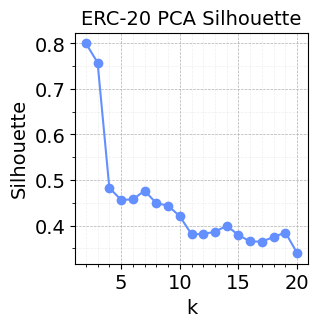

In [28]:
fig, ax = plt.subplots(figsize=(3, 3))
ax.set_title('ERC-20 PCA Silhouette')
ax.set_xlabel('k')
ax.set_ylabel('Silhouette')
ax.plot(result['k'], result['silhouette'], marker='o', color='#648fff')
ax.grid(which='major', linestyle='--', linewidth=0.5)
ax.grid(which='minor', linestyle='--', linewidth=0.5, alpha=0.2)
ax.xaxis.set_minor_locator(matplotlib.ticker.AutoMinorLocator(5))
ax.yaxis.set_minor_locator(matplotlib.ticker.AutoMinorLocator(2))
utils.set_font_size(ax, 14)
plt.savefig('figures/ft_pca_silhouette.pdf', format='pdf', bbox_inches='tight')
plt.show()

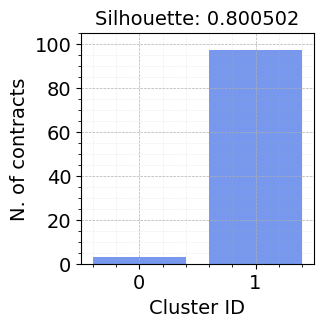

In [29]:
data = StandardScaler().fit_transform(ft_prep[FEATURES])
pca = PCA(n_components=3)
X = pca.fit_transform(data)
kmeans = KMeans(init='k-means++', n_clusters=2, n_init=100, max_iter=1000, random_state=1)
pred_labels = kmeans.fit_predict(X)
sil = silhouette_score(X, pred_labels)
result = pl.DataFrame(X).with_columns(label = pred_labels).to_pandas() #.assign(category = final.category)
plt.figure(figsize=(3, 3))
plt.title(f'Silhouette: {round(sil, 6)}')
sns.countplot(x='label', color='#648fff', data=result)
plt.xlabel('Cluster ID')
plt.ylabel('N. of contracts')
plt.grid(which='major', linestyle='--', linewidth=0.5)
plt.grid(which='minor', linestyle='--', linewidth=0.5, alpha=0.2)
plt.minorticks_on()
plt.ylim(top=105)
utils.set_font_size(plt.gca(), 14)
plt.savefig('figures/ft_pca_clustering.pdf', format='pdf', bbox_inches='tight')
plt.show()

We print the details about the configurations with $k=8$ yielding the highest silhouette and homogeneity scores.

In [30]:
conf = kmeans_results.filter(pl.col("k") == 8)
print(conf.sort("silhouette", descending=True)[0])
print(conf.sort("homogeneity", descending=True)[0])

shape: (1, 4)
┌──────────┬─────┬────────────┬─────────────┐
│ features ┆ k   ┆ silhouette ┆ homogeneity │
│ ---      ┆ --- ┆ ---        ┆ ---         │
│ str      ┆ i64 ┆ f64        ┆ f64         │
╞══════════╪═════╪════════════╪═════════════╡
│ coverage ┆ 8   ┆ 0.899257   ┆ 0.092461    │
└──────────┴─────┴────────────┴─────────────┘
shape: (1, 4)
┌───────────────────────────┬─────┬────────────┬─────────────┐
│ features                  ┆ k   ┆ silhouette ┆ homogeneity │
│ ---                       ┆ --- ┆ ---        ┆ ---         │
│ str                       ┆ i64 ┆ f64        ┆ f64         │
╞═══════════════════════════╪═════╪════════════╪═════════════╡
│ coverage diameter est_apl ┆ 8   ┆ 0.349785   ┆ 0.235004    │
└───────────────────────────┴─────┴────────────┴─────────────┘


In [31]:
colors=['#8dd3c7','#ffffb3','#bebada','#fb8072','#80b1d3','#fdb462','#b3de69','#fccde5','#d9d9d9']
cmap = LinearSegmentedColormap.from_list('my_cmap', colors)
categories = ft_prep['category_id'].to_numpy()

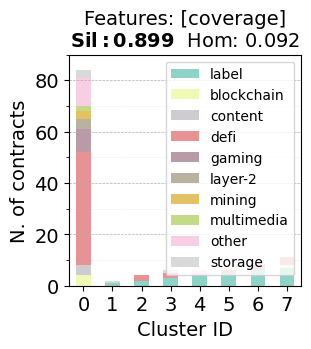

In [32]:
features = ['coverage']
k = 8
features_str = ' '.join(features)
clust_data = PowerTransformer().fit_transform(ft_prep[features])
kmeans = KMeans(init='k-means++', n_clusters=k, n_init=100, max_iter=1000, random_state=1)
pred_labels = kmeans.fit_predict(clust_data)
sil = silhouette_score(clust_data, pred_labels)
hom = homogeneity_score(categories, pred_labels)
result = pl.DataFrame(clust_data).with_columns(label = pred_labels).with_columns(category=ft_prep['category'])
xt = result.pivot(on="category", index="label", values="label", aggregate_function="len", sort_columns=True).sort("label").fill_null(0)

fig, ax = plt.subplots(figsize=(3, 3))
xt.to_pandas().plot(kind='bar', stacked=True, ax = ax, cmap=cmap, legend=False)
ax.set_title(f'Features: [{features_str}]\n' + r'$\bf{Sil: {' + str(round(sil, 3)) + r'}}$' + f'  Hom: {round(hom, 3)}')
ax.set_xlabel('Cluster ID')
ax.set_ylabel('N. of contracts')
ax.set_xticklabels(ax.get_xticks(), rotation = 0)
ax.yaxis.grid(which='major', linestyle='--', linewidth=0.5)
ax.yaxis.grid(which='minor', linestyle='--', linewidth=0.5, alpha=0.2)
ax.yaxis.set_minor_locator(matplotlib.ticker.AutoMinorLocator(2))
ax.set_ylim(top=90)
ax.legend(loc='upper right')
utils.set_font_size(ax, 14)
plt.savefig('figures/ft_hom_1.pdf', format='pdf', bbox_inches='tight')
plt.show()

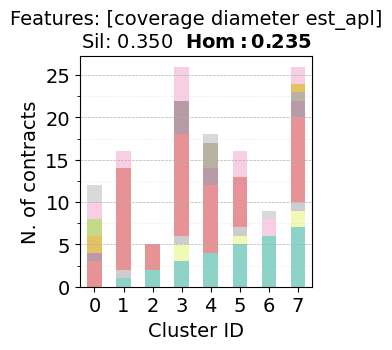

In [34]:
features = ['coverage', 'diameter', 'est_apl']
k = 8
features_str = ' '.join(features)
clust_data = PowerTransformer().fit_transform(ft_prep[features])
kmeans = KMeans(init='k-means++', n_clusters=k, n_init=100, max_iter=1000, random_state=1)
pred_labels = kmeans.fit_predict(clust_data)
sil = silhouette_score(clust_data, pred_labels)
hom = homogeneity_score(categories, pred_labels)
result = pl.DataFrame(clust_data).with_columns(label=pred_labels, category=ft_prep['category'])
xt = result.pivot(on="category", index="label", values="label", aggregate_function="len", sort_columns=True).sort("label").fill_null(0)

fig, ax = plt.subplots(figsize=(3, 3))
xt.to_pandas().plot(kind='bar', stacked=True, ax = ax, cmap=cmap, legend=False)
ax.set_title(f'Features: [{features_str}]\n' + 'Sil: {:.3f}  '.format(sil) + r'$\bf{Hom: {' + str(round(hom,3)) + r'}}$')
#+ r'$\bf{Sil: {' + str(round(sil, 3)) + r'}}$' + f'  Hom: {round(hom, 3)}')
ax.set_xlabel('Cluster ID')
ax.set_ylabel('N. of contracts')
ax.set_xticklabels(ax.get_xticks(), rotation = 0)
ax.yaxis.grid(which='major', linestyle='--', linewidth=0.5)
ax.yaxis.grid(which='minor', linestyle='--', linewidth=0.5, alpha=0.2)
ax.yaxis.set_minor_locator(matplotlib.ticker.AutoMinorLocator(2))
#ax.set_ylim(top=50)
#ax.legend(loc='upper right')
utils.set_font_size(ax, 14)
plt.savefig('figures/ft_hom_2.pdf', format='pdf', bbox_inches='tight')
plt.show()

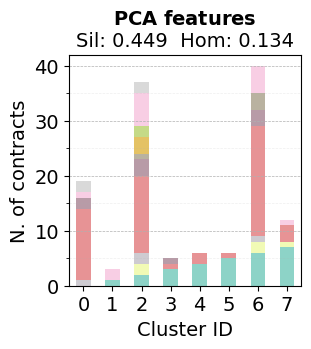

In [35]:
features = ['coverage', 'diameter', 'est_apl', 'transitivity', 'density']
k = 8
data = StandardScaler().fit_transform(ft_prep[features])
pca = PCA(n_components=3)
X = pca.fit_transform(data)
kmeans = KMeans(init='k-means++', n_clusters=k, n_init=100, max_iter=1000, random_state=1)
pred_labels = kmeans.fit_predict(X)
sil = silhouette_score(X, pred_labels)
hom = homogeneity_score(categories, pred_labels)
result = pl.DataFrame(data).with_columns(label=pred_labels, category=ft_prep['category'])
xt = result.pivot(on="category", index="label", values="label", aggregate_function="len", sort_columns=True).sort("label").fill_null(0)

fig, ax = plt.subplots(figsize=(3, 3))
xt.to_pandas().plot(kind='bar', stacked=True, ax = ax, cmap=cmap, legend=False)
ax.set_title(r"$\bf{PCA\ features}$" + f"\nSil: {round(sil, 3)}  Hom: {round(hom, 3)}")
ax.set_xlabel('Cluster ID')
ax.set_ylabel('N. of contracts')
ax.set_xticklabels(ax.get_xticks(), rotation = 0)
ax.yaxis.grid(which='major', linestyle='--', linewidth=0.5)
ax.yaxis.grid(which='minor', linestyle='--', linewidth=0.5, alpha=0.2)
ax.yaxis.set_minor_locator(matplotlib.ticker.AutoMinorLocator(2))
#ax.set_ylim(top=50)
utils.set_font_size(ax, 14)
plt.savefig('figures/ft_hom_3.pdf', format='pdf', bbox_inches='tight')
plt.show()

## Results for ERC-721 tokens

We repeat the same experiments as before for ERC-721 networks.

In [2]:
nft_prep = pl.read_csv('results/nft/clustering/nft_prep.csv')
nft_prep

rank,category,category_id,comp_nodes,coverage,diameter,est_apl,transitivity,density
i64,str,i64,i64,f64,f64,f64,f64,f64
0,"""domain-names""",4,475139,0.999952,11.934486,0.189888,0.000003,0.000005
1,"""gaming""",1,6841,0.967746,1.245656,0.354859,0.009671,0.001005
2,"""gaming""",1,29821,0.99943,0.970594,0.24464,0.010292,0.00068
3,"""art""",2,52451,0.953949,1.472261,0.411514,0.0186517,0.000124
4,"""art""",2,47934,0.998271,2.783556,0.197647,0.000015,0.000046
…,…,…,…,…,…,…,…,…
95,"""pfps""",0,18458,0.968365,2.74858,0.638165,0.003304,0.000165
96,"""pfps""",0,16950,0.974194,2.156495,0.657548,0.003704,0.000186
97,"""pfps""",0,10963,0.998634,1.720008,0.481739,0.0019507,0.000407


In [3]:
nft_prep["category"].value_counts(sort=True)

category,count
str,u32
"""pfps""",48
"""gaming""",18
"""art""",14
"""other""",13
"""virtual-worlds""",5
"""domain-names""",2


These are the results of the k-means clustering process.

In [4]:
kmeans_results = pl.read_csv('results/nft/clustering/nft_kmeans.csv')
kmeans_results

features,k,silhouette,homogeneity
str,i64,f64,f64
"""coverage""",2,0.746909,0.014691
"""coverage""",3,0.733027,0.033858
"""coverage""",4,0.693253,0.052207
"""coverage""",5,0.662845,0.077832
"""coverage""",6,0.664838,0.106051
…,…,…,…
"""coverage diameter est_apl tran…",16,0.318583,0.557304
"""coverage diameter est_apl tran…",17,0.321567,0.54684
"""coverage diameter est_apl tran…",18,0.323332,0.612761


We now proceed as follows.

1. We select the best configuration for each feature subset, in accordance with the silhouette score.
2. We select the top 3 configurations yielding the highest silhouette score.
3. We visualize (with a bar plot) the compositions of clusters in these 3 configurations.

In [6]:
kmeans_results.sort("silhouette", descending=True).group_by("features", maintain_order=True).head(1).head(3)

features,k,silhouette,homogeneity
str,i64,f64,f64
"""coverage""",2,0.746909,0.014691
"""transitivity""",20,0.66538,0.453699
"""diameter""",3,0.659975,0.187302


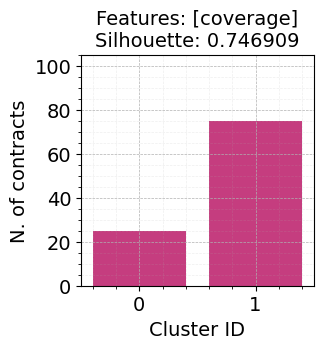

In [7]:
plot_clustering(nft_prep, ['coverage'], 2, color="#dc267f", filename='figures/nft_kmeans_top_1.pdf')

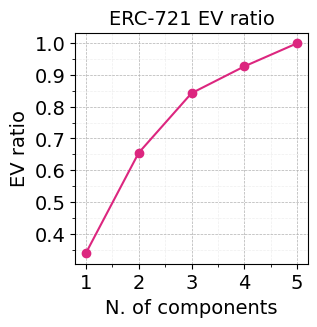

In [8]:
data = StandardScaler().fit_transform(nft_prep[FEATURES])
pca = PCA()
pca.fit(data)

fig, ax = plt.subplots(figsize=(3, 3))
ax.set_title('ERC-721 EV ratio')
ax.set_xlabel('N. of components')
ax.set_ylabel('EV ratio')
ax.plot(range(1, 6), pca.explained_variance_ratio_.cumsum(), marker='o', color='#dc267f')
ax.grid(which='major', linestyle='--', linewidth=0.5)
ax.grid(which='minor', linestyle='--', linewidth=0.5, alpha=0.2)
ax.xaxis.set_minor_locator(matplotlib.ticker.AutoMinorLocator(2))
ax.yaxis.set_minor_locator(matplotlib.ticker.AutoMinorLocator(2))
utils.set_font_size(ax, 14)

plt.savefig('figures/nft_pca_explained_variance.pdf', format='pdf', bbox_inches='tight')
plt.show()

We select $n=3$ as the optimal number of components (preserving at least 80% of the orginal variance) and then execute K-means for different values of $k$ (i.e., ranging from 2 to 20, included). Below, we print the silhouette scores obtained for different values of $k$.

In [11]:
data = StandardScaler().fit_transform(nft_prep[FEATURES])
pca = PCA(n_components=3)
X = pca.fit_transform(data)
kmin = 2
kmax = 20
sil = []
for k in np.arange(kmin, kmax+1):
    kmeans = KMeans(init='k-means++', n_clusters=k, n_init=100, max_iter=1000, random_state=1)
    pred_labels = kmeans.fit_predict(X)
    sil.append(silhouette_score(X, pred_labels))
result = pl.DataFrame({'k' : np.arange(kmin, kmax+1), 'silhouette' : sil})
result

k,silhouette
i64,f64
2,0.576905
3,0.498529
4,0.529623
5,0.446625
6,0.417971
…,…
16,0.41272
17,0.398338
18,0.400792


Then we plot the silhouette scores obtained for different values of $k$.

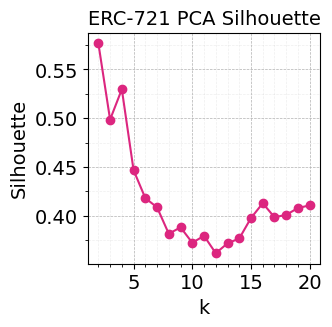

In [13]:
fig, ax = plt.subplots(figsize=(3, 3))
ax.set_title('ERC-721 PCA Silhouette')
ax.set_xlabel('k')
ax.set_ylabel('Silhouette')
ax.plot(result['k'], result['silhouette'], marker='o', color='#dc267f')
ax.grid(which='major', linestyle='--', linewidth=0.5)
ax.grid(which='minor', linestyle='--', linewidth=0.5, alpha=0.2)
ax.xaxis.set_minor_locator(matplotlib.ticker.AutoMinorLocator(5))
ax.yaxis.set_minor_locator(matplotlib.ticker.AutoMinorLocator(2))
utils.set_font_size(ax, 14)
plt.savefig('figures/nft_pca_silhouette.pdf', format='pdf', bbox_inches='tight')
plt.show()

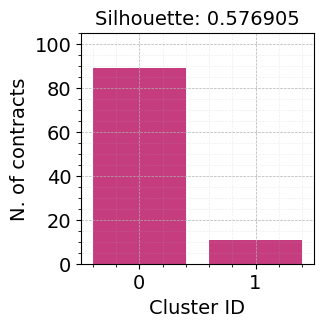

In [14]:
data = StandardScaler().fit_transform(nft_prep[FEATURES])
pca = PCA(n_components=3)
X = pca.fit_transform(data)
kmeans = KMeans(init='k-means++', n_clusters=2, n_init=100, max_iter=1000, random_state=1)
pred_labels = kmeans.fit_predict(X)
sil = silhouette_score(X, pred_labels)
result = pl.DataFrame(X).with_columns(label = pred_labels).to_pandas()
plt.figure(figsize=(3, 3))
plt.title(f'Silhouette: {round(sil, 6)}')
sns.countplot(x='label', color='#dc267f', data=result)
plt.xlabel('Cluster ID')
plt.ylabel('N. of contracts')
plt.grid(which='major', linestyle='--', linewidth=0.5)
plt.grid(which='minor', linestyle='--', linewidth=0.5, alpha=0.2)
plt.minorticks_on()
plt.ylim(top=105)
utils.set_font_size(plt.gca(), 14)
plt.savefig('figures/nft_pca_clustering.pdf', format='pdf', bbox_inches='tight')
plt.show()

Now, let us consider all K-means configurations obtained for $k=5$. Among them we select:

- The one yielding the maximum silhouette score.
- The one yielding the maximum homogeneity score.

In [18]:
print(kmeans_results.filter(pl.col("k") == 5).sort("silhouette", descending=True)[0])
print(kmeans_results.filter(pl.col("k") == 5).sort("homogeneity", descending=True)[0])

shape: (1, 4)
┌──────────┬─────┬────────────┬─────────────┐
│ features ┆ k   ┆ silhouette ┆ homogeneity │
│ ---      ┆ --- ┆ ---        ┆ ---         │
│ str      ┆ i64 ┆ f64        ┆ f64         │
╞══════════╪═════╪════════════╪═════════════╡
│ coverage ┆ 5   ┆ 0.662845   ┆ 0.077832    │
└──────────┴─────┴────────────┴─────────────┘
shape: (1, 4)
┌──────────────────────────┬─────┬────────────┬─────────────┐
│ features                 ┆ k   ┆ silhouette ┆ homogeneity │
│ ---                      ┆ --- ┆ ---        ┆ ---         │
│ str                      ┆ i64 ┆ f64        ┆ f64         │
╞══════════════════════════╪═════╪════════════╪═════════════╡
│ coverage est_apl density ┆ 5   ┆ 0.464929   ┆ 0.375396    │
└──────────────────────────┴─────┴────────────┴─────────────┘


In [ ]:
colors = ['#66c2a5','#fc8d62','#8da0cb','#e78ac3','#a6d854','#ffd92f']
cmap = LinearSegmentedColormap.from_list('my_cmap', colors)
categories = nft_prep['category_id'].to_numpy()

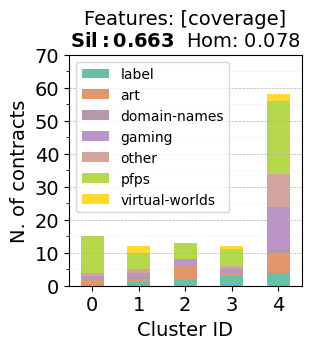

In [20]:
features = ['coverage']
k = 5
features_str = ' '.join(features)
clust_data = PowerTransformer().fit_transform(nft_prep[features])
kmeans = KMeans(init='k-means++', n_clusters=k, n_init=100, max_iter=1000, random_state=1)
pred_labels = kmeans.fit_predict(clust_data)
sil = silhouette_score(clust_data, pred_labels)
hom = homogeneity_score(categories, pred_labels)
result = pl.DataFrame(clust_data).with_columns(label = pred_labels, category = nft_prep['category'])
xt = result.pivot(on="category", index="label", values="label", aggregate_function="len", sort_columns=True).sort("label").fill_null(0)

fig, ax = plt.subplots(figsize=(3, 3))
xt.to_pandas().plot(kind='bar', stacked=True, ax = ax, cmap=cmap, legend=False)
ax.set_title(f'Features: [{features_str}]\n' + r'$\bf{Sil: {' + str(round(sil, 3)) + r'}}$' + f'  Hom: {round(hom, 3)}')
ax.set_xlabel('Cluster ID')
ax.set_ylabel('N. of contracts')
ax.set_xticklabels(ax.get_xticks(), rotation = 0)
ax.yaxis.grid(which='major', linestyle='--', linewidth=0.5)
ax.yaxis.grid(which='minor', linestyle='--', linewidth=0.5, alpha=0.2)
ax.yaxis.set_minor_locator(matplotlib.ticker.AutoMinorLocator(2))
ax.set_ylim(top=70)
ax.legend(loc='upper left')
utils.set_font_size(ax, 14)
plt.savefig('figures/nft_hom_1.pdf', format='pdf', bbox_inches='tight')
plt.show()

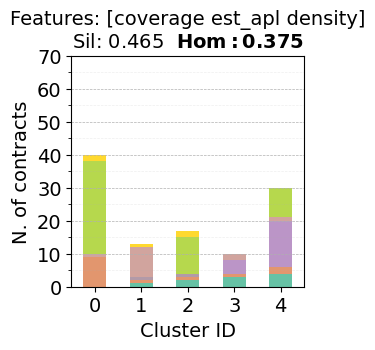

In [22]:
features = ['coverage', 'est_apl', 'density']
k = 5
features_str = ' '.join(features)
clust_data = PowerTransformer().fit_transform(nft_prep[features])
kmeans = KMeans(init='k-means++', n_clusters=k, n_init=100, max_iter=1000, random_state=1)
pred_labels = kmeans.fit_predict(clust_data)
sil = silhouette_score(clust_data, pred_labels)
hom = homogeneity_score(categories, pred_labels)
result = pl.DataFrame(clust_data).with_columns(label = pred_labels, category = nft_prep['category'])
xt = result.pivot(on="category", index="label", values="label", aggregate_function="len", sort_columns=True).sort("label").fill_null(0)

fig, ax = plt.subplots(figsize=(3, 3))
xt.to_pandas().plot(kind='bar', stacked=True, ax = ax, cmap=cmap, legend=False)
title = f'Features: [coverage est_apl density]\n' + \
    'Sil: {:.3f}  '.format(sil) + r'$\bf{Hom: {' + str(round(hom,3)) + r'}}$'
ax.set_title(title)
ax.set_xlabel('Cluster ID')
ax.set_ylabel('N. of contracts')
ax.set_xticklabels(ax.get_xticks(), rotation = 0)
ax.yaxis.grid(which='major', linestyle='--', linewidth=0.5)
ax.yaxis.grid(which='minor', linestyle='--', linewidth=0.5, alpha=0.2)
ax.yaxis.set_minor_locator(matplotlib.ticker.AutoMinorLocator(2))
ax.set_ylim(top=70)
utils.set_font_size(ax, 14)
plt.savefig('figures/nft_hom_2.pdf', format='pdf', bbox_inches='tight')
plt.show()

Finally, we also plot the cluster subdivision for the configuration obtained with $k=5$ on the PCA-reduced data set.

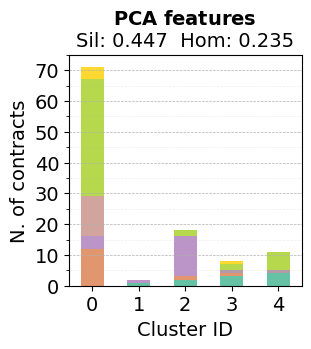

In [23]:
features = ['coverage', 'diameter', 'est_apl', 'transitivity', 'density']
k = 5
data = StandardScaler().fit_transform(nft_prep[features])
pca = PCA(n_components=3)
X = pca.fit_transform(data)
kmeans = KMeans(init='k-means++', n_clusters=5, n_init=100, max_iter=1000, random_state=1)
pred_labels = kmeans.fit_predict(X)
sil = silhouette_score(X, pred_labels)
hom = homogeneity_score(categories, pred_labels)
result = pl.DataFrame(data).with_columns(label = pred_labels, category = nft_prep['category'])
xt = result.pivot(on="category", index="label", values="label", aggregate_function="len", sort_columns=True).sort("label").fill_null(0)

fig, ax = plt.subplots(figsize=(3, 3))
xt.to_pandas().plot(kind='bar', stacked=True, ax = ax, cmap=cmap, legend=False)
ax.set_title(r"$\bf{PCA\ features}$" + f"\nSil: {round(sil, 3)}  Hom: {round(hom, 3)}")
ax.set_xlabel('Cluster ID')
ax.set_ylabel('N. of contracts')
ax.set_xticklabels(ax.get_xticks(), rotation = 0)
ax.yaxis.grid(which='major', linestyle='--', linewidth=0.5)
ax.yaxis.grid(which='minor', linestyle='--', linewidth=0.5, alpha=0.2)
ax.yaxis.set_minor_locator(matplotlib.ticker.AutoMinorLocator(2))
ax.set_ylim(top=75)
utils.set_font_size(ax, 14)
plt.savefig('figures/nft_hom_3.pdf', format='pdf', bbox_inches='tight')
plt.show()